In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import os
os.getcwd()
os.chdir(r"C:\Users\athar\Downloads")
import scipy
from scipy import stats

import numpy as np
from numpy import random
import pandas as pd
import scipy
from scipy import stats

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend #heading, referred as label/scale
from pylab import plot, show, title, xlabel, ylabel 

import scipy
from scipy import stats
from scipy.stats import binom,poisson
from scipy.stats import expon
from scipy.stats import norm,t


In [88]:
import os
os.getcwd()
os.chdir(r"C:\Users\athar\Downloads")

In [3]:
df=pd.read_excel("CDAC_DataBook.xlsx",sheet_name="ERPData")

In [4]:
grp1=df.groupby('Location')

In [5]:
grp1.groups

{'MWH-1': [1, 9, 10, 24, 25, 26, 39, 40, 41, 48, 49], 'MWH-2': [2, 7, 8, 15, 35, 36, 42, 45, 46], 'MWH-3': [14, 43, 44, 47], 'MWH-4': [0, 4, 5, 6, 11, 12, 13, 18, 19, 20, 21, 22, 30, 31, 32], 'MWH-5': [3, 16, 17, 23, 27, 28, 29, 33, 34, 37, 38]}

In [6]:
grp1.get_group('MWH-2')

,MaterialID,Location,Quantity
2,LXCV-21,MWH-2,27
7,TMI-43T,MWH-2,29
8,GCVB-79,MWH-2,10
15,GCVB-79,MWH-2,87
35,GCVB-79,MWH-2,31
36,GCVB-79,MWH-2,28
42,SDRT-67,MWH-2,31
45,DDBN-89,MWH-2,69
46,AXCP-78,MWH-2,85


In [7]:
grp1.Quantity.agg(['sum','size'])

,sum,size
Location,,
MWH-1,889,11
MWH-2,397,9
MWH-3,174,4
MWH-4,728,15
MWH-5,697,11


In [8]:
df2=grp1.agg(['sum','size'])

In [9]:
df2=grp1.agg(np.sum).Quantity

In [10]:
df2
type(df2)

pandas.core.series.Series

In [11]:
df2=grp1.agg(np.sum).Quantity.reset_index()
df2
#Ask this to sir

,Location,Quantity
0,MWH-1,889
1,MWH-2,397
2,MWH-3,174
3,MWH-4,728
4,MWH-5,697


In [12]:
grp1.Quantity.count().reset_index()

,Location,Quantity
0,MWH-1,11
1,MWH-2,9
2,MWH-3,4
3,MWH-4,15
4,MWH-5,11


In [13]:
grp1.Quantity.sum().reset_index()

,Location,Quantity
0,MWH-1,889
1,MWH-2,397
2,MWH-3,174
3,MWH-4,728
4,MWH-5,697


In [14]:
df2=grp1.agg(['sum','size'])

In [15]:
grp1.agg(np.sum)

,MaterialID,Quantity
Location,,
MWH-1,AXCP-78TMI-43TSDRT-67AXCP-78AXCP-78DDBN-89AXCP...,889
MWH-2,LXCV-21TMI-43TGCVB-79GCVB-79GCVB-79GCVB-79SDRT...,397
MWH-3,TMI-43TDDBN-89LXCV-21AXCP-78,174
MWH-4,TMI-43TAXCP-78TMI-43TTMI-43TSDRT-67TMI-43TTMI-...,728
MWH-5,AXCP-78SDRT-67SDRT-67DDBN-89LXCV-21LXCV-21LXCV...,697


In [16]:
grp1.Quantity.agg(['sum'])

,sum
Location,
MWH-1,889
MWH-2,397
MWH-3,174
MWH-4,728
MWH-5,697


In [17]:
#whats the difference betn this three above ones and which one is used where?


In [18]:
grp2=df.groupby(['MaterialID','Location'])
grp2.groups

{('AXCP-78', 'MWH-1'): [1, 24, 25, 39, 48], ('AXCP-78', 'MWH-2'): [46], ('AXCP-78', 'MWH-3'): [47], ('AXCP-78', 'MWH-4'): [4], ('AXCP-78', 'MWH-5'): [3, 37, 38], ('DDBN-89', 'MWH-1'): [26, 40, 49], ('DDBN-89', 'MWH-2'): [45], ('DDBN-89', 'MWH-3'): [43], ('DDBN-89', 'MWH-4'): [22, 30], ('DDBN-89', 'MWH-5'): [23], ('GCVB-79', 'MWH-2'): [8, 15, 35, 36], ('GCVB-79', 'MWH-5'): [34], ('LXCV-21', 'MWH-2'): [2], ('LXCV-21', 'MWH-3'): [44], ('LXCV-21', 'MWH-5'): [27, 28, 29], ('SDRT-67', 'MWH-1'): [10, 41], ('SDRT-67', 'MWH-2'): [42], ('SDRT-67', 'MWH-4'): [11], ('SDRT-67', 'MWH-5'): [16, 17], ('TMI-43T', 'MWH-1'): [9], ('TMI-43T', 'MWH-2'): [7], ('TMI-43T', 'MWH-3'): [14], ('TMI-43T', 'MWH-4'): [0, 5, 6, 12, 13, 18, 19, 20, 21, 31, 32], ('TMI-43T', 'MWH-5'): [33]}

In [21]:
len(df.MaterialID)

50

In [22]:
np.unique(df.MaterialID)

array(['AXCP-78', 'DDBN-89', 'GCVB-79', 'LXCV-21', 'SDRT-67', 'TMI-43T'],
      dtype=object)

In [31]:
mat_count=df.MaterialID.value_counts().reset_index()
type(mat_count)
mat_count

,MaterialID,count
0,TMI-43T,15
1,AXCP-78,11
2,DDBN-89,8
3,SDRT-67,6
4,LXCV-21,5
5,GCVB-79,5


In [37]:
df1=df.groupby(df.MaterialID)

In [38]:
df1.groups

{'AXCP-78': [1, 3, 4, 24, 25, 37, 38, 39, 46, 47, 48], 'DDBN-89': [22, 23, 26, 30, 40, 43, 45, 49], 'GCVB-79': [8, 15, 34, 35, 36], 'LXCV-21': [2, 27, 28, 29, 44], 'SDRT-67': [10, 11, 16, 17, 41, 42], 'TMI-43T': [0, 5, 6, 7, 9, 12, 13, 14, 18, 19, 20, 21, 31, 32, 33]}

In [40]:
mat_count['Proportion']=mat_count['count']/sum(mat_count['count'])
mat_count

,MaterialID,count,Proportion
0,TMI-43T,15,0.30
1,AXCP-78,11,0.22
2,DDBN-89,8,0.16
3,SDRT-67,6,0.12
4,LXCV-21,5,0.10
5,GCVB-79,5,0.10


In [42]:
mat_count['Percentage']=mat_count['count']*100/sum(mat_count['count'])
mat_count

,MaterialID,count,Proportion,Percentage
0,TMI-43T,15,0.30,30.0
1,AXCP-78,11,0.22,22.0
2,DDBN-89,8,0.16,16.0
3,SDRT-67,6,0.12,12.0
4,LXCV-21,5,0.10,10.0
5,GCVB-79,5,0.10,10.0


In [44]:
grades=np.array(['A','A','B','C','B','A'])
grades

array(['A', 'A', 'B', 'C', 'B', 'A'], dtype='<U1')

In [46]:
np.unique(grades,return_counts=True)

(array(['A', 'B', 'C'], dtype='<U1'), array([3, 2, 1], dtype=int64))

In [49]:
df=pd.read_excel('covid_cases.xlsx')
df

,State,Cases
0,UP,250
1,KA,350
2,MH,650
3,KL,400
4,MP,350
5,AP,150
6,TG,100
7,TN,150


In [54]:
df['Prop']=df.Cases/sum(df.Cases)
df

,State,Cases,Prop
0,UP,250,0.104167
1,KA,350,0.145833
2,MH,650,0.270833
3,KL,400,0.166667
4,MP,350,0.145833
5,AP,150,0.062500
6,TG,100,0.041667
7,TN,150,0.062500


In [59]:
df1=df.sort_values('Prop',ascending=False)
df1

,State,Cases,Prop
2,MH,650,0.270833
3,KL,400,0.166667
1,KA,350,0.145833
4,MP,350,0.145833
0,UP,250,0.104167
5,AP,150,0.062500
7,TN,150,0.062500
6,TG,100,0.041667


In [62]:
df2=np.cumsum(df1.Prop)
df2

2    0.270833
3    0.437500
1    0.583333
4    0.729167
0    0.833333
5    0.895833
7    0.958333
6    1.000000
Name: Prop, dtype: float64

In [63]:
df2.iloc[2]

0.5833333333333334

In [65]:
df=pd.read_excel("CDAC_DataBook.xlsx",sheet_name='faithful')
df

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85
...,...,...
267,4.117,81
268,2.150,46
269,4.417,90
270,1.817,46


In [74]:
erupt=df['eruptions']

In [75]:
erupt

0      3.600
1      1.800
2      3.333
3      2.283
4      4.533
       ...  
267    4.117
268    2.150
269    4.417
270    1.817
271    4.467
Name: eruptions, Length: 272, dtype: float64

In [76]:
sum(erupt)

948.677

In [77]:
np.mean(erupt)

3.4877830882352936

In [81]:
x1=np.sort(erupt)
len(x1)

272

In [84]:
marks={20:8,35:9,15:10}
df=np.array([[20,35,15],[8,9,10]])
df1=df[0]*df[1]
df1

array([160, 315, 150])

In [85]:
df2=df1.sum()

(array([  5.,  10., 150., 140., 120., 100.,  80.,  60.,  40.,  20.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

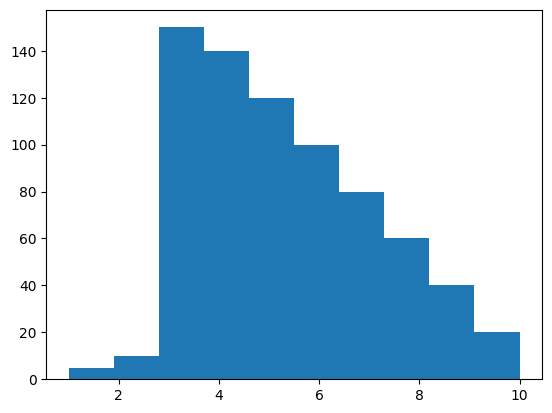

In [97]:
x1 = np.repeat([1,2,3,4,5,6,7,8,9,10],[5,10,150,140,120,100,80,60,40,20])
plt.hist(x1)

In [102]:
plt.show()


-0.48916996679169217

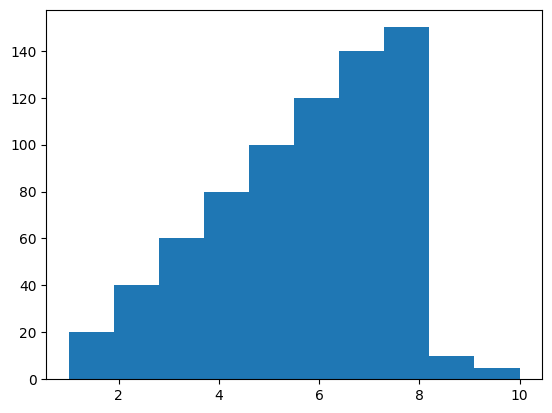

In [101]:
x2 = np.repeat([1,2,3,4,5,6,7,8,9,10],[20,40,60,80,100,120,140,150,10,5])

plt.hist(x2)
scipy.stats.skew(x2)

<BarContainer object of 4 artists>

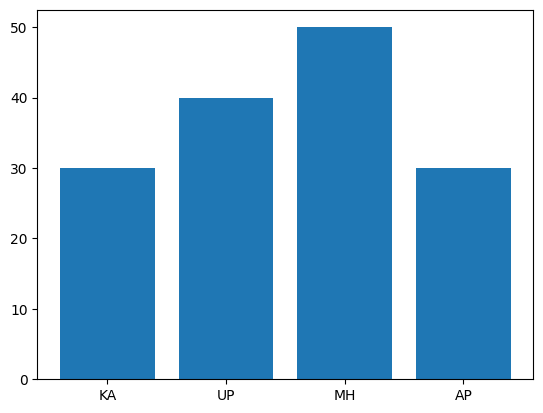

In [105]:
states=['KA','UP','MH','AP']
counts=[30,40,50,30]
plt.bar(states,counts)

In [110]:
df1=pd.DataFrame([states],[counts])

Text(0.5, 1.0, 'State Representation')

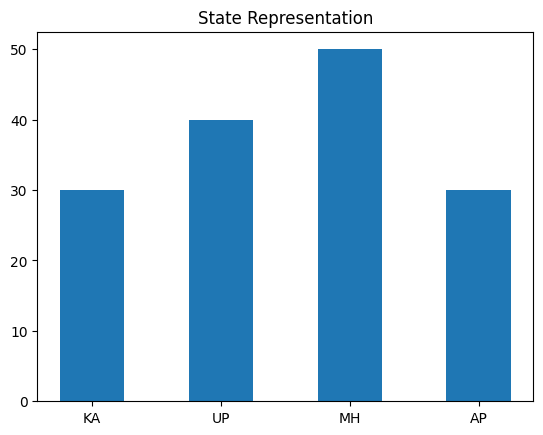

In [112]:
plt.bar(states,counts,width=0.5)
plt.title("State Representation")

In [115]:
#x=locatn y= quantity

df=pd.read_excel('CDAC_DataBook.xlsx',sheet_name='ERPData')
df

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36
5,TMI-43T,MWH-4,78
6,TMI-43T,MWH-4,31
7,TMI-43T,MWH-2,29
8,GCVB-79,MWH-2,10
9,TMI-43T,MWH-1,120


In [116]:
df1=df['Location'].value_counts().reset_index()

<BarContainer object of 5 artists>

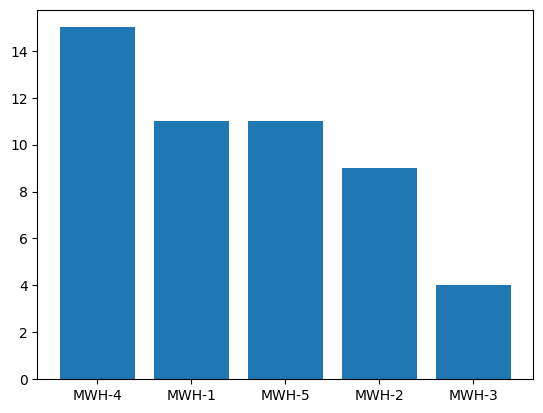

In [117]:
plt.bar(df1['Location'],df1['count'])

In [118]:
plt.show()

In [ ]:
#when the data is categorical, to plot diff frequences of categorical data we use bar plot

In [121]:
from numpy import random
age=np.array([23,4,32,55,7,23,87,12,88])
catg=[]
for i in age:
    if (i<10):
        catg.append("A")
    elif(i<50):
        catg.append("B")
    else:
        catg.append("C")

catg

['B', 'A', 'B', 'C', 'A', 'B', 'C', 'B', 'C']

In [ ]:
df=df.pivot_table